<a href="https://colab.research.google.com/github/amyziyi97-prog/llm-visibility-improvement/blob/main/Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

In [ ]:
# =========================
# Load experiment results
# =========================

coffee_files = [
    "coffee_results_batch_1.csv",
    "coffee_results_batch_2.csv",
    "coffee_results_batch_3.csv",
    "coffee_results_batch_4.csv"
]

vacuum_files = [
    "vacuum_results_batch_1.csv",
    "vacuum_results_batch_2.csv",
    "vacuum_results_batch_3.csv",
    "vacuum_results_batch_4.csv"
]

coffee_results_df = pd.concat(
    [pd.read_csv(f, encoding="latin1") for f in coffee_files],
    ignore_index=True
)

vacuum_results_df = pd.concat(
    [pd.read_csv(f, encoding="latin1") for f in vacuum_files],
    ignore_index=True
)

coffee_results_df["product_typology"] = "Experience Good"
vacuum_results_df["product_typology"] = "Search Good"

combined_results_df = pd.concat(
    [coffee_results_df, vacuum_results_df],
    ignore_index=True
)

BASELINE_NAME = "1_Baseline"

display(combined_results_df.head())
print(combined_results_df.shape)

,product_category,product_typology,batch_id,condition,iteration,raw_response,brand,brand_role,is_leader,is_challenger,rank,rrs,prominence_score,word_count,mentioned_text,trust_score,purchase_intent_score,persona_scores
0,Coffee Beans,Experience Good,1,1_Baseline,1,"Based on the provided search results, here are...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.00,0.165,60,Ethiopia Yirgacheffe Reserve â This is the t...,NaN,NaN,NaN
1,Coffee Beans,Experience Good,1,1_Baseline,1,"Based on the provided search results, here are...",NovaBean Heritage,Challenger,0,1,5,0.20,0.088,48,5. NovaBean Heritage â An excellent all-purp...,5.0,4.3,"{'budget_buyer': {'trust_score': 5, 'purchase_..."
2,Coffee Beans,Experience Good,1,1_Baseline,2,"Based on the provided search results, here are...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.00,0.169,50,"Ethiopia Yirgacheffe Reserve ($28.00, Rating: ...",NaN,NaN,NaN
3,Coffee Beans,Experience Good,1,1_Baseline,2,"Based on the provided search results, here are...",NovaBean Heritage,Challenger,0,1,4,0.25,0.109,43,"NovaBean Heritage ($19.00, Rating: 4.3) â A ...",4.0,3.3,"{'budget_buyer': {'trust_score': 4, 'purchase_..."
4,Coffee Beans,Experience Good,1,1_Baseline,3,"Based on the provided search results, here are...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.00,0.165,52,Ethiopia Yirgacheffe Reserve ($28.00) - This i...,NaN,NaN,NaN


(3200, 18)


# 2. Core Analysis Functions



In [ ]:
# ANALYTICAL METRICS
# ============================================================
# A. Relative Percentage Gain
# Only for challenger
# ΔMetric = (Metric_condition - Metric_baseline) / Metric_baseline
# ----------------------------------------------------------
def compute_relative_gain(df, dv_col, baseline_name=BASELINE_NAME):
    df_ch = df[df["is_challenger"] == 1].copy()

    baseline_df = (
        df_ch[df_ch["condition"] == baseline_name]
        [["product_typology", "iteration", "brand", dv_col]]
        .rename(columns={dv_col: f"{dv_col}_baseline"})
    )

    merged = df_ch.merge(
        baseline_df,
        on=["product_typology", "iteration", "brand"],
        how="left"
    )

    merged["relative_gain"] = np.where(
        merged[f"{dv_col}_baseline"].fillna(0) == 0,
        np.nan,
        (merged[dv_col] - merged[f"{dv_col}_baseline"]) / merged[f"{dv_col}_baseline"]
    )

    return merged

# ------------------------------------------------------------
# B. Visibility Gap
# Gap = Leader - Challenger
# ------------------------------------------------------------
def compute_visibility_gap(df, dv_col):
    gap_rows = []

    for (typology, condition, iteration), g in df.groupby(
        ["product_typology", "condition", "iteration"]
    ):
        leader_val = g[g["is_leader"] == 1][dv_col].mean()
        challenger_val = g[g["is_challenger"] == 1][dv_col].mean()

        gap_rows.append({
            "product_typology": typology,
            "condition": condition,
            "iteration": iteration,
            "leader_value": leader_val,
            "challenger_value": challenger_val,
            "gap": leader_val - challenger_val
        })

    return pd.DataFrame(gap_rows)

# ------------------------------------------------------------
# C. Gap Reduction
# Gap Reduction = Gap_baseline - Gap_strategy
# positive = Challenger narrows the gap
# ------------------------------------------------------------
def compute_gap_reduction(gap_df, baseline_name=BASELINE_NAME):
    baseline_gap = (
        gap_df[gap_df["condition"] == baseline_name]
        [["product_typology", "iteration", "gap"]]
        .rename(columns={"gap": "gap_baseline"})
    )
    merged = gap_df.merge(baseline_gap, on=["product_typology", "iteration"], how="left")
    merged["gap_reduction"] = merged["gap_baseline"] - merged["gap"]

    return merged

# ------------------------------------------------------------
# D. Wilcoxon signed-rank test
# Challenger only, within each product typology.
# ------------------------------------------------------------
def run_wilcoxon_against_baseline(df, dv_col, baseline_name=BASELINE_NAME):
    output = []

    df_ch = df[df["is_challenger"] == 1].copy()

    baseline = (
        df_ch[df_ch["condition"] == baseline_name]
        [["product_typology", "iteration", "brand", dv_col]]
        .rename(columns={dv_col: "baseline_dv"})
    )

    for (typology, strategy), current in df_ch.groupby(["product_typology", "condition"]):
        if strategy == baseline_name:
            continue

        merged = current[["product_typology", "iteration", "brand", dv_col]].merge(
            baseline,
            on=["product_typology", "iteration", "brand"],
            how="inner"
        )

        merged_clean = merged.dropna(subset=[dv_col, "baseline_dv"])

        if len(merged) < 2:
            stat, p_value = np.nan, np.nan
        else:
            try:
                stat, p_value = wilcoxon(merged[dv_col], merged["baseline_dv"])
            except ValueError:
                stat, p_value = np.nan, np.nan

        output.append({
            "product_typology": typology,
            "dv": dv_col,
            "strategy": strategy,
            "n_pairs": len(merged),
            "wilcoxon_stat": stat,
            "p_value": p_value,
            "mean_strategy": merged[dv_col].mean(),
            "mean_baseline": merged["baseline_dv"].mean()
        })

    return pd.DataFrame(output)

# 3. Run Analysis

In [ ]:
dv_cols = [
    "rrs",
    "prominence_score",
    "trust_score",
    "purchase_intent_score"
]

gain_dfs = {
    dv: compute_relative_gain(combined_results_df, dv_col=dv)
    for dv in dv_cols
}

gap_rrs_df = compute_visibility_gap(combined_results_df, dv_col="rrs")
gap_imp_df = compute_visibility_gap(combined_results_df, dv_col="prominence_score")

gap_reduction_rrs_df = compute_gap_reduction(gap_rrs_df)
gap_reduction_imp_df = compute_gap_reduction(gap_imp_df)

wilcoxon_df = pd.concat(
    [run_wilcoxon_against_baseline(combined_results_df, dv_col=dv) for dv in dv_cols],
    ignore_index=True
)

# 4. Final Tables

In [ ]:
# Table 1: Descriptive Statistics

table_descriptive = (
    combined_results_df
    .groupby(["product_typology", "condition", "brand_role"])
    .agg(
        mean_rank=("rank", "mean"),
        sd_rank=("rank", "std"),
        mean_rrs=("rrs", "mean"),
        sd_rrs=("rrs", "std"),
        mean_imp_pwc=("prominence_score", "mean"),
        sd_imp_pwc=("prominence_score", "std"),
        mean_trust=("trust_score", "mean"),
        sd_trust=("trust_score", "std"),
        mean_purchase_intent=("purchase_intent_score", "mean"),
        sd_purchase_intent=("purchase_intent_score", "std"),
        n=("iteration", "count")
    )
    .reset_index()
)

display(table_descriptive)
table_descriptive.to_csv(
    "table_descriptive.csv",index=False,encoding="utf-8-sig")

,product_typology,condition,brand_role,mean_rank,sd_rank,mean_rrs,sd_rrs,mean_imp_pwc,sd_imp_pwc,mean_trust,sd_trust,mean_purchase_intent,sd_purchase_intent,n
0,Experience Good,1_Baseline,Challenger,4.95,1.028631,0.20445,0.041518,0.09471,0.016431,4.167677,0.322246,3.487879,0.323019,100
1,Experience Good,1_Baseline,Leader,1.00,0.000000,1.00000,0.000000,0.17855,0.024498,NaN,NaN,NaN,NaN,100
2,Experience Good,2_Keyword_Stuffing,Challenger,5.00,0.921132,0.20674,0.036736,0.09472,0.013286,4.108000,0.289088,3.573000,0.437822,100
3,Experience Good,2_Keyword_Stuffing,Leader,1.00,0.000000,1.00000,0.000000,0.17845,0.021500,NaN,NaN,NaN,NaN,100
4,Experience Good,3_Statistics_Addition,Challenger,4.91,0.779731,0.20892,0.033007,0.10309,0.015186,4.539000,0.356440,3.980000,0.301176,100
5,Experience Good,3_Statistics_Addition,Leader,1.00,0.000000,1.00000,0.000000,0.17616,0.019244,NaN,NaN,NaN,NaN,100
6,Experience Good,4_Citation_Injection,Challenger,4.91,0.817671,0.20916,0.033300,0.09690,0.010490,4.325000,0.360240,3.685000,0.383070,100
7,Experience Good,4_Citation_Injection,Leader,1.00,0.000000,1.00000,0.000000,0.18045,0.020261,NaN,NaN,NaN,NaN,100
8,Experience Good,5_Fluency_Optimization,Challenger,5.15,0.925235,0.20063,0.036053,0.09430,0.015329,4.062000,0.295686,3.571000,0.354850,100
9,Experience Good,5_Fluency_Optimization,Leader,1.00,0.000000,1.00000,0.000000,0.18338,0.022778,NaN,NaN,NaN,NaN,100


In [ ]:
df = combined_results_df.copy()
df_ch = df[df["is_challenger"] == 1]

# Only Experience Good
df_eg = df_ch[df_ch["product_typology"] == "Experience Good"]

pivot = df_eg.pivot_table(
    index="iteration",
    columns="condition",
    values="trust_score"
)

display(pivot.head(20))

test = pivot[["1_Baseline", "3_Statistics_Addition"]]

print("valid paired observations：")
print(test.dropna().shape[0])

condition,1_Baseline,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
iteration,,,,,,,,
1,5.0,4.3,4.0,4.7,4.0,4.0,3.0,3.7
2,4.0,4.0,4.0,4.3,4.3,4.0,3.3,4.7
3,4.3,4.3,4.3,4.7,4.0,4.0,4.0,4.7
4,4.0,3.7,5.0,4.0,3.7,4.0,3.7,3.7
5,4.0,3.3,4.7,4.7,4.3,4.0,4.0,3.7
6,4.0,4.3,4.3,4.0,4.7,4.0,3.7,3.7
7,4.0,4.0,4.0,4.7,4.0,3.0,4.0,4.7
8,4.0,4.0,4.7,4.7,4.0,4.0,4.0,4.0
9,4.3,4.0,5.0,4.7,4.0,4.0,4.0,3.7


valid paired observations：
99


In [ ]:
# Table 2: Relative Percentage Gain

table_relative_gain = None

for dv, df_gain in gain_dfs.items():
    tmp = (
        df_gain
        .groupby(["product_typology", "condition"])
        .agg(**{f"mean_relative_gain_{dv}": ("relative_gain", "mean")})
        .reset_index()
    )

    if table_relative_gain is None:
        table_relative_gain = tmp
    else:
        table_relative_gain = table_relative_gain.merge(
            tmp,
            on=["product_typology", "condition"],
            how="outer"
        )

display(table_relative_gain)

,product_typology,condition,mean_relative_gain_rrs,mean_relative_gain_prominence_score,mean_relative_gain_trust_score,mean_relative_gain_purchase_intent_score
0,Experience Good,1_Baseline,0.000000,0.000000,0.000000,0.000000
1,Experience Good,2_Keyword_Stuffing,0.029319,0.008209,-0.008242,0.032685
2,Experience Good,3_Statistics_Addition,0.042737,0.099786,0.093993,0.150097
3,Experience Good,4_Citation_Injection,0.038086,0.032177,0.041817,0.062638
4,Experience Good,5_Fluency_Optimization,-0.003548,0.002252,-0.019859,0.032012
5,Experience Good,6_Easy_to_Understand,0.050533,0.064132,-0.005954,0.055514
6,Experience Good,7_Authoritative_Tone,0.096383,0.076748,-0.072152,0.039128
7,Experience Good,8_Comparative_Synthesis,0.084887,0.063332,-0.034699,0.077155
8,Search Good,1_Baseline,0.000000,0.000000,0.000000,0.000000
9,Search Good,2_Keyword_Stuffing,-0.006063,0.064830,0.140081,0.340832


In [ ]:
# Table 3: Visibility Gap
table_gap_rrs = (
    gap_rrs_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_rrs=("gap", "mean"))
    .reset_index()
)

table_gap_imp = (
    gap_imp_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_imp_pwc=("gap", "mean"))
    .reset_index()
)

table_gap = table_gap_rrs.merge(
    table_gap_imp,
    on=["product_typology", "condition"],
    how="outer"
)

display(table_gap)

,product_typology,condition,mean_gap_rrs,mean_gap_imp_pwc
0,Experience Good,1_Baseline,0.79555,0.08384
1,Experience Good,2_Keyword_Stuffing,0.79326,0.08373
2,Experience Good,3_Statistics_Addition,0.79108,0.07307
3,Experience Good,4_Citation_Injection,0.79084,0.08355
4,Experience Good,5_Fluency_Optimization,0.79937,0.08908
5,Experience Good,6_Easy_to_Understand,0.78907,0.07741
6,Experience Good,7_Authoritative_Tone,0.78067,0.07777
7,Experience Good,8_Comparative_Synthesis,0.78243,0.08093
8,Search Good,1_Baseline,0.76631,0.07986
9,Search Good,2_Keyword_Stuffing,0.78395,0.07798


In [ ]:
# Table 4: Gap Reduction
table_gap_reduction_rrs = (
    gap_reduction_rrs_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_reduction_rrs=("gap_reduction", "mean"))
    .reset_index()
)

table_gap_reduction_imp = (
    gap_reduction_imp_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_reduction_imp_pwc=("gap_reduction", "mean"))
    .reset_index()
)

table_gap_reduction = table_gap_reduction_rrs.merge(
    table_gap_reduction_imp,
    on=["product_typology", "condition"],
    how="outer"
)

display(table_gap_reduction)

,product_typology,condition,mean_gap_reduction_rrs,mean_gap_reduction_imp_pwc
0,Experience Good,1_Baseline,0.00000,0.00000
1,Experience Good,2_Keyword_Stuffing,0.00229,0.00011
2,Experience Good,3_Statistics_Addition,0.00447,0.01077
3,Experience Good,4_Citation_Injection,0.00471,0.00029
4,Experience Good,5_Fluency_Optimization,-0.00382,-0.00524
5,Experience Good,6_Easy_to_Understand,0.00648,0.00643
6,Experience Good,7_Authoritative_Tone,0.01488,0.00607
7,Experience Good,8_Comparative_Synthesis,0.01312,0.00291
8,Search Good,1_Baseline,0.00000,0.00000
9,Search Good,2_Keyword_Stuffing,-0.01764,0.00188


In [ ]:
# Table 5: Wilcoxon Tests
display(wilcoxon_df)

,product_typology,dv,strategy,n_pairs,wilcoxon_stat,p_value,mean_strategy,mean_baseline
0,Experience Good,rrs,2_Keyword_Stuffing,100,973.5,9.830498e-01,0.206740,0.204450
1,Experience Good,rrs,3_Statistics_Addition,100,1241.5,8.323084e-01,0.208920,0.204450
2,Experience Good,rrs,4_Citation_Injection,100,1047.5,5.624184e-01,0.209160,0.204450
3,Experience Good,rrs,5_Fluency_Optimization,100,661.5,3.574714e-01,0.200630,0.204450
4,Experience Good,rrs,6_Easy_to_Understand,100,962.0,2.627289e-01,0.210930,0.204450
5,Experience Good,rrs,7_Authoritative_Tone,100,757.0,1.541389e-02,0.219330,0.204450
6,Experience Good,rrs,8_Comparative_Synthesis,100,576.5,1.847931e-02,0.217570,0.204450
7,Search Good,rrs,2_Keyword_Stuffing,100,1088.5,1.987807e-01,0.206050,0.213690
8,Search Good,rrs,3_Statistics_Addition,100,116.0,5.096525e-10,0.251140,0.213690
9,Search Good,rrs,4_Citation_Injection,100,269.0,6.069144e-07,0.238500,0.213690


# 5. Visibility Convergence Heatmap

In [ ]:
heatmap_df = (
    gap_reduction_rrs_df
    .query("condition != @BASELINE_NAME")
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_reduction=("gap_reduction", "mean"))
    .reset_index()
)

heatmap_matrix = heatmap_df.pivot(
    index="product_typology",
    columns="condition",
    values="mean_gap_reduction"
)

display(heatmap_matrix)

condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,0.00229,0.00447,0.00471,-0.00382,0.00648,0.01488,0.01312
Search Good,-0.01764,0.04745,0.03981,-0.00538,-0.00644,0.02979,0.03311


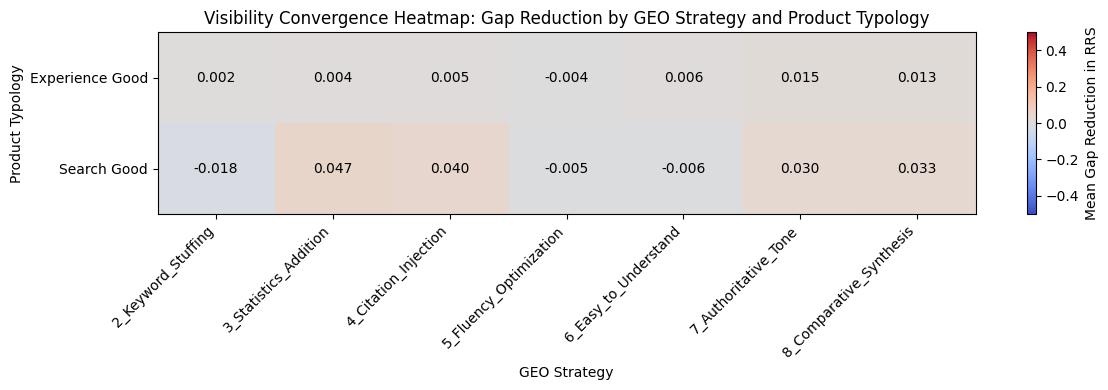

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

data = heatmap_matrix.values
im = ax.imshow(data, aspect="auto", cmap="coolwarm", vmin=-0.5, vmax=0.5)

ax.set_xticks(np.arange(len(heatmap_matrix.columns)))
ax.set_yticks(np.arange(len(heatmap_matrix.index)))

ax.set_xticklabels(heatmap_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_matrix.index)

ax.set_title("Visibility Convergence Heatmap: Gap Reduction by GEO Strategy and Product Typology")
ax.set_xlabel("GEO Strategy")
ax.set_ylabel("Product Typology")

for i in range(len(heatmap_matrix.index)):
    for j in range(len(heatmap_matrix.columns)):
        value = data[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.3f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Mean Gap Reduction in RRS")

plt.tight_layout()
plt.show()

# Relative Percentage Gain heatmap

In [ ]:
for dv in ["rrs", "prominence_score", "trust_score", "purchase_intent_score"]:

  heatmap_gain_df = (
      gain_dfs[dv]
      .query("condition != @BASELINE_NAME")
      .groupby(["product_typology", "condition"])
      .agg(mean_relative_gain=("relative_gain", "mean"))
      .reset_index()
  )

  heatmap_gain_matrix = heatmap_gain_df.pivot(
      index="product_typology",
      columns="condition",
      values="mean_relative_gain"
  )
  print(f"Relative {dv}")
  display(heatmap_gain_matrix)

Relative rrs


condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,0.029319,0.042737,0.038086,-0.003548,0.050533,0.096383,0.084887
Search Good,-0.006063,0.210395,0.150688,0.047847,-0.026961,0.193956,0.066742


Relative prominence_score


condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,0.008209,0.099786,0.032177,0.002252,0.064132,0.076748,0.063332
Search Good,0.064830,0.238337,0.214754,0.048658,0.056167,0.160726,0.090506


Relative trust_score


condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,-0.008242,0.093993,0.041817,-0.019859,-0.005954,-0.072152,-0.034699
Search Good,0.140081,0.096591,0.047382,0.012091,0.001197,-0.075869,-0.025927


Relative purchase_intent_score


condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,0.032685,0.150097,0.062638,0.032012,0.055514,0.039128,0.077155
Search Good,0.340832,0.212945,0.091035,0.055506,0.006925,-0.026483,0.015047


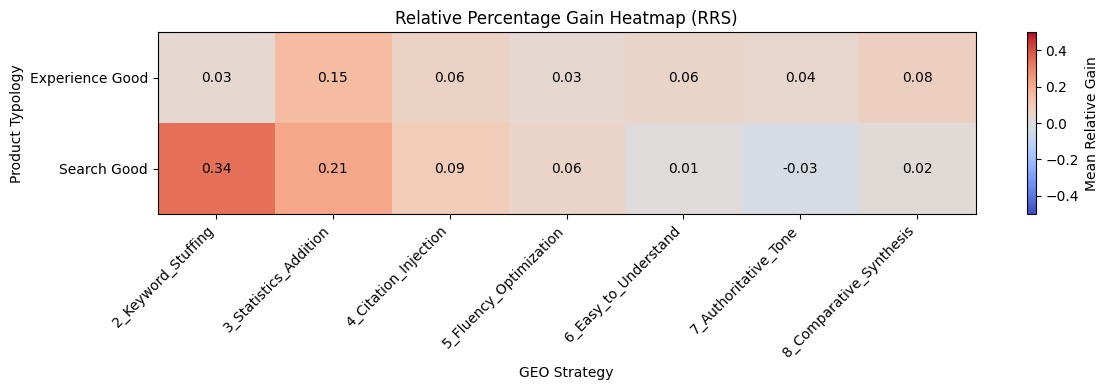

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

data = heatmap_gain_matrix.values

im = ax.imshow(data, aspect="auto", cmap="coolwarm", vmin=-0.5, vmax=0.5)

# ticks
ax.set_xticks(np.arange(len(heatmap_gain_matrix.columns)))
ax.set_yticks(np.arange(len(heatmap_gain_matrix.index)))

ax.set_xticklabels(heatmap_gain_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_gain_matrix.index)

# labels
ax.set_title("Relative Percentage Gain Heatmap (RRS)")
ax.set_xlabel("GEO Strategy")
ax.set_ylabel("Product Typology")

# values inside cells
for i in range(len(heatmap_gain_matrix.index)):
    for j in range(len(heatmap_gain_matrix.columns)):
        value = data[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Mean Relative Gain")

plt.tight_layout()
plt.show()